<a href="https://colab.research.google.com/github/Sunil032003/Restaurant-review-NLP-/blob/main/NLP_Movie_Review_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NLP Project 3: Movie Review Classification
Using the IMDb dataset with `review` and `sentiment` columns.

In [ ]:
# Install once if needed
# !pip install nltk wordcloud scikit-learn


In [1]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from wordcloud import WordCloud

nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [3]:
# Load Dataset
df = pd.read_csv('IMDB Dataset.csv')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


,0
review,0
sentiment,0


In [7]:
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def preprocess(text):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-Z]", " ", text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)


In [8]:
df["clean_review"] = df["review"].apply(preprocess)

In [9]:
X=df['clean_review']
y=df['sentiment']

tfidf=TfidfVectorizer(max_features=5000)
X=tfidf.fit_transform(X)

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y)


In [10]:
model=LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

pred=model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred))
print(classification_report(y_test,pred))


Accuracy: 0.8924
              precision    recall  f1-score   support

    negative       0.90      0.88      0.89      5000
    positive       0.89      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



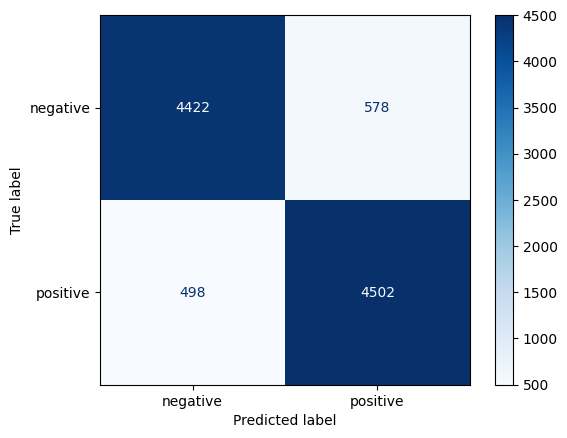

In [11]:
cm=confusion_matrix(y_test,pred)
ConfusionMatrixDisplay(confusion_matrix=cm,
                       display_labels=model.classes_).plot(cmap='Blues')
plt.show()


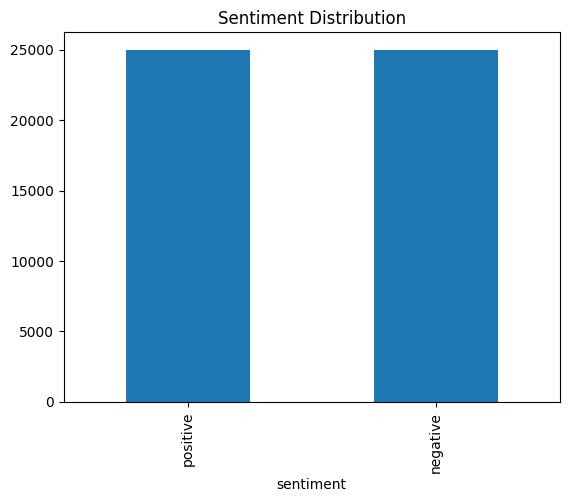

In [12]:
df['sentiment'].value_counts().plot(kind='bar')
plt.title('Sentiment Distribution')
plt.show()


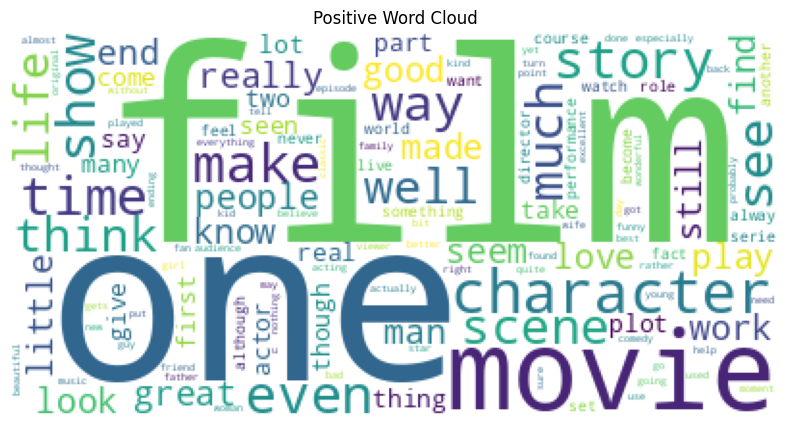

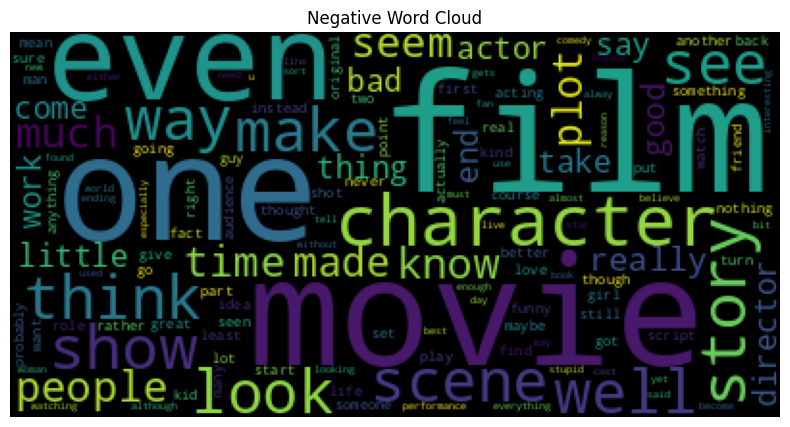

In [13]:
positive=' '.join(df[df.sentiment=='positive']['clean_review'])
negative=' '.join(df[df.sentiment=='negative']['clean_review'])

plt.figure(figsize=(10,5))
plt.imshow(WordCloud(background_color='white').generate(positive))
plt.axis('off')
plt.title('Positive Word Cloud')
plt.show()

plt.figure(figsize=(10,5))
plt.imshow(WordCloud(background_color='black').generate(negative))
plt.axis('off')
plt.title('Negative Word Cloud')
plt.show()
